In [2]:

#Loading the required libraries

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pennylane as qml
import math

In [3]:
# -------------------------------
# 1) Build a coordinate grid for a w×h image
def get_rect_mgrid(width, height):
    """
    Returns a tensor of shape [width*height, 2], where each row is
    an (x, y) coordinate in [-1,1]×[-1,1].
    """
    xs = torch.linspace(-1, 1, steps=width)
    ys = torch.linspace(-1, 1, steps=height)
    X, Y = torch.meshgrid(xs, ys, indexing='ij')           # each shape [height, width]
    mgrid = torch.vstack((X.flatten(), Y.flatten())).T      # shape [height*width, 2]
    return mgrid

In [4]:
#Pre-processing

from PIL import Image
import numpy as np
import torch

# 1) Load RGB image and resize
img_path = "johnwick.png"
img = Image.open(img_path).convert("RGB")       # Load RGB image
img = img.resize((64, 64), Image.BILINEAR)      
arr = np.array(img).astype("float32") / 255.0   
H, W, C = arr.shape                             

# 2) Flatten image into pixels [H*W, 3]
pixels = torch.from_numpy(arr).view(-1, 3)      

# 3) Create coordinate grid [H*W, 2]
coords = get_rect_mgrid(W, H)                   

# 4) Move tensors to device
device = torch.device("cpu")  # or "cuda" if available
coords = coords.to(device)
pixels = pixels.to(device)

# 5) Add batch dimension
coords_batch = coords.unsqueeze(0)              
pixels_batch = pixels.unsqueeze(0)            

# Confirm shapes
print("coords_batch shape:", coords_batch.shape)
print("pixels_batch shape:", pixels_batch.shape)


coords_batch shape: torch.Size([1, 4096, 2])
pixels_batch shape: torch.Size([1, 4096, 3])


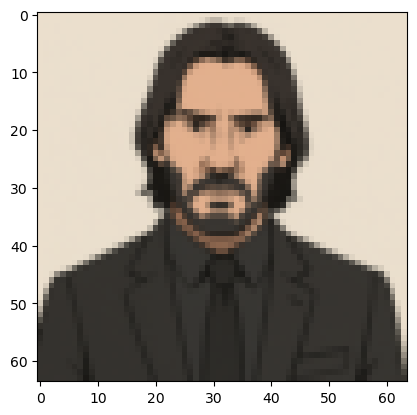

In [5]:
plt.imshow(img, cmap='gray')

In [5]:
print("coords dtype:", coords.dtype)
print("coords min/max:", coords.min().item(), coords.max().item())


coords dtype: torch.float32
coords min/max: -1.0 1.0


In [6]:
#Architecture
#Quantum–classical model(QIREN)

import torch
import torch.nn as nn
import pennylane as qml
import numpy as np

in_features  = 2          # (x,y)
n_qubits     = 7
hidden_layers = 2
n_entangling_layers = 6
out_channels =3

class QuantumLayer(nn.Module):
   
    def __init__(self, in_features):
        super().__init__()
        self.in_features = in_features
        dev = qml.device("default.qubit", wires=in_features)
        
        
        #@qml.qnode(dev, interface="torch", diff_method="backprop")
        @qml.qnode(dev, interface="torch")
        def circuit(inputs, w1, w2, w3):
        
            qml.StronglyEntanglingLayers(w1, wires=range(in_features))
            qml.AngleEmbedding(inputs, wires=range(in_features))
            qml.StronglyEntanglingLayers(w1, wires=range(in_features))
            
            
            qml.AngleEmbedding(inputs *0.5, wires=range(in_features))
            qml.StronglyEntanglingLayers(w2, wires=range(in_features))
            
            
            qml.AngleEmbedding(inputs*2, wires=range(in_features))
            qml.StronglyEntanglingLayers(w3, wires=range(in_features))
            
            
            return qml.probs(wires=range(in_features))
        
        
        self.qnn = qml.qnn.TorchLayer(
            circuit,
            {
                "w1": (n_entangling_layers, in_features, 3),
                "w2": (n_entangling_layers, in_features, 3),
                "w3": (n_entangling_layers, in_features, 3),
            },
        )
    
    
    def forward(self, x):
        B, N, _ = x.shape
        out = self.qnn(x.reshape(-1, self.in_features))   # [B·N, 2^F] probabilities
        return out.reshape(B, N, -1)                      # [B, N, 2^F]

class HybridLayer(nn.Module):
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.linear = nn.Linear(in_feat, out_feat)
        self.norm   = nn.BatchNorm1d(out_feat)
        self.q      = QuantumLayer(out_feat)
        
        
        self.proj = nn.Linear(2**out_feat, out_feat)
    
    def forward(self, x):
        h = self.linear(x)
        h = self.norm(h.permute(0,2,1)).permute(0,2,1)
        q_out = self.q(h)  # [B, N, 2^out_feat]
        
        
        return self.proj(q_out)  # [B, N, out_feat]

class Hybridren(nn.Module):
    def __init__(self, in_feat, n_qubits, hidden_layers, out_feat=out_channels):
        super().__init__()
        layers = [HybridLayer(in_feat, n_qubits)]
        for _ in range(hidden_layers):
            layers.append(HybridLayer(n_qubits, n_qubits))
        layers.append(nn.Linear(n_qubits, out_feat))
        self.net = nn.Sequential(*layers)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True)
        return self.net(coords), coords

In [7]:
model = Hybridren(in_feat=2, n_qubits=n_qubits, hidden_layers=hidden_layers)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Hybridren(
  (net): Sequential(
    (0): HybridLayer(
      (linear): Linear(in_features=2, out_features=7, bias=True)
      (norm): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (q): QuantumLayer(
        (qnn): <Quantum Torch Layer: func=circuit>
      )
      (proj): Linear(in_features=128, out_features=7, bias=True)
    )
    (1): HybridLayer(
      (linear): Linear(in_features=7, out_features=7, bias=True)
      (norm): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (q): QuantumLayer(
        (qnn): <Quantum Torch Layer: func=circuit>
      )
      (proj): Linear(in_features=128, out_features=7, bias=True)
    )
    (2): HybridLayer(
      (linear): Linear(in_features=7, out_features=7, bias=True)
      (norm): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (q): QuantumLayer(
        (qnn): <Quantum Torch Layer: func=circuit>
      )
      (proj): Linear(in_features=1

In [8]:
# -------------------------------
# 7) Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)  # lr=1e-3


In [ ]:
#Training Loop


import torch
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- Early stopping params ---
patience        = 75
min_delta       = 1e-5
best_loss       = float("inf")
patience_counter = 0

EPOCHS = 1000

# --- PSNR helper function ---
def compute_psnr(mse):
    if mse == 0:
        return float("inf")
    return 10 * math.log10(1.0 / mse)

# --- Scheduler (no verbose=True) ---
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
)

# --- Training loop ---
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out, _ = model(coords_batch)
    loss = criterion(out, pixels_batch)

    # Backward + step
    loss.backward()
    optimizer.step()

    # Compute PSNR
    mse_val = loss.item()
    psnr_val = compute_psnr(mse_val)

    # Print loss and PSNR
    print(f"Loss = {mse_val:.6f}    PSNR = {psnr_val:.2f} dB")

    # Step the scheduler
    scheduler.step(mse_val)

    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current learning rate: {current_lr:.6e}")

    # --- Early stopping ---
    if mse_val + min_delta < best_loss:
        best_loss = mse_val
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

# --- Save model ---
save_path = "hybridren8qbitsdebugged64_modelscratch1.pth"
torch.save(model.state_dict(), save_path)
print(f"\nModel saved to {save_path}")



Epoch 1/1000
Loss = 0.277769    PSNR = 5.56 dB
Current learning rate: 3.000000e-02

Epoch 2/1000
Loss = 0.222427    PSNR = 6.53 dB
Current learning rate: 3.000000e-02

Epoch 3/1000
Loss = 0.168188    PSNR = 7.74 dB
Current learning rate: 3.000000e-02

Epoch 4/1000
Loss = 0.126654    PSNR = 8.97 dB
Current learning rate: 3.000000e-02

Epoch 5/1000
Loss = 0.111083    PSNR = 9.54 dB
Current learning rate: 3.000000e-02

Epoch 6/1000
Loss = 0.118755    PSNR = 9.25 dB
Current learning rate: 3.000000e-02

Epoch 7/1000
Loss = 0.130031    PSNR = 8.86 dB
Current learning rate: 3.000000e-02

Epoch 8/1000
Loss = 0.129140    PSNR = 8.89 dB
Current learning rate: 3.000000e-02

Epoch 9/1000
Loss = 0.118126    PSNR = 9.28 dB
Current learning rate: 3.000000e-02

Epoch 10/1000
Loss = 0.106730    PSNR = 9.72 dB
Current learning rate: 3.000000e-02

Epoch 11/1000
Loss = 0.098046    PSNR = 10.09 dB
Current learning rate: 3.000000e-02

Epoch 12/1000
Loss = 0.090745    PSNR = 10.42 dB
Current learning rate: 

In [9]:
save_path = "hybridren7qbitsdebugged64_modelscratch1.pth"

/tmp/ipykernel_7961/495051280.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(save_path, map_location=device))


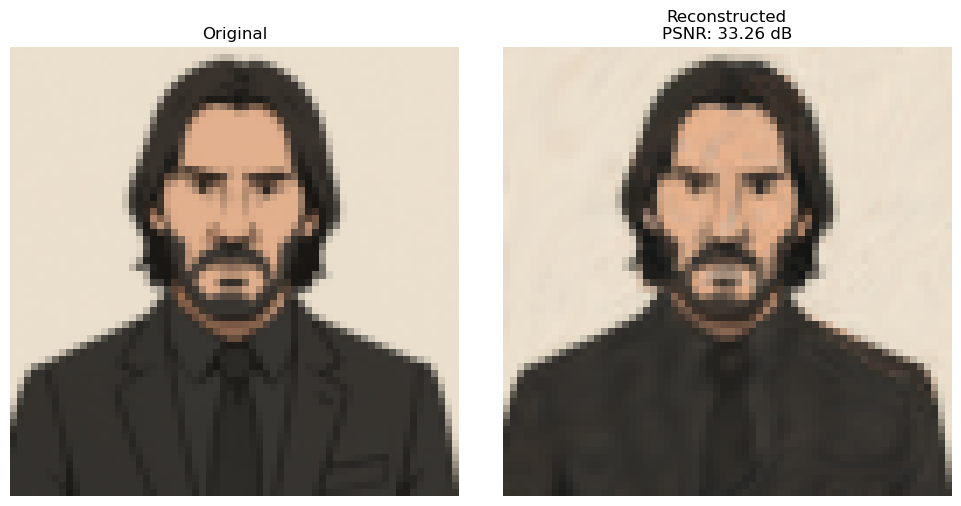

In [10]:
#Image Fitting Task


import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Load model
model = Hybridren(in_feat=2, n_qubits=n_qubits, hidden_layers=hidden_layers)
loaded_model = Hybridren(in_feat=2, n_qubits=n_qubits, hidden_layers=hidden_layers)
loaded_model.load_state_dict(torch.load(save_path, map_location=device))
loaded_model.eval()

# Model forward pass
with torch.no_grad():
    recon_tensor, _ = loaded_model(coords_batch)  # [1, 4096, 3]
    recon_tensor = recon_tensor.squeeze(0).cpu().view(H, W, 3)  # [H, W, 3]
    recon_arr = recon_tensor.numpy()  # float32 in [0, 1]


def compute_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val) - 10 * np.log10(mse)


psnr_val = compute_psnr(arr, recon_arr)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow((arr * 255.0).astype(np.uint8))
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(np.clip(recon_arr * 255.0, 0, 255).astype(np.uint8))
ax[1].set_title(f'Reconstructed\nPSNR: {psnr_val:.2f} dB')
ax[1].axis('off')

plt.tight_layout()
plt.show()




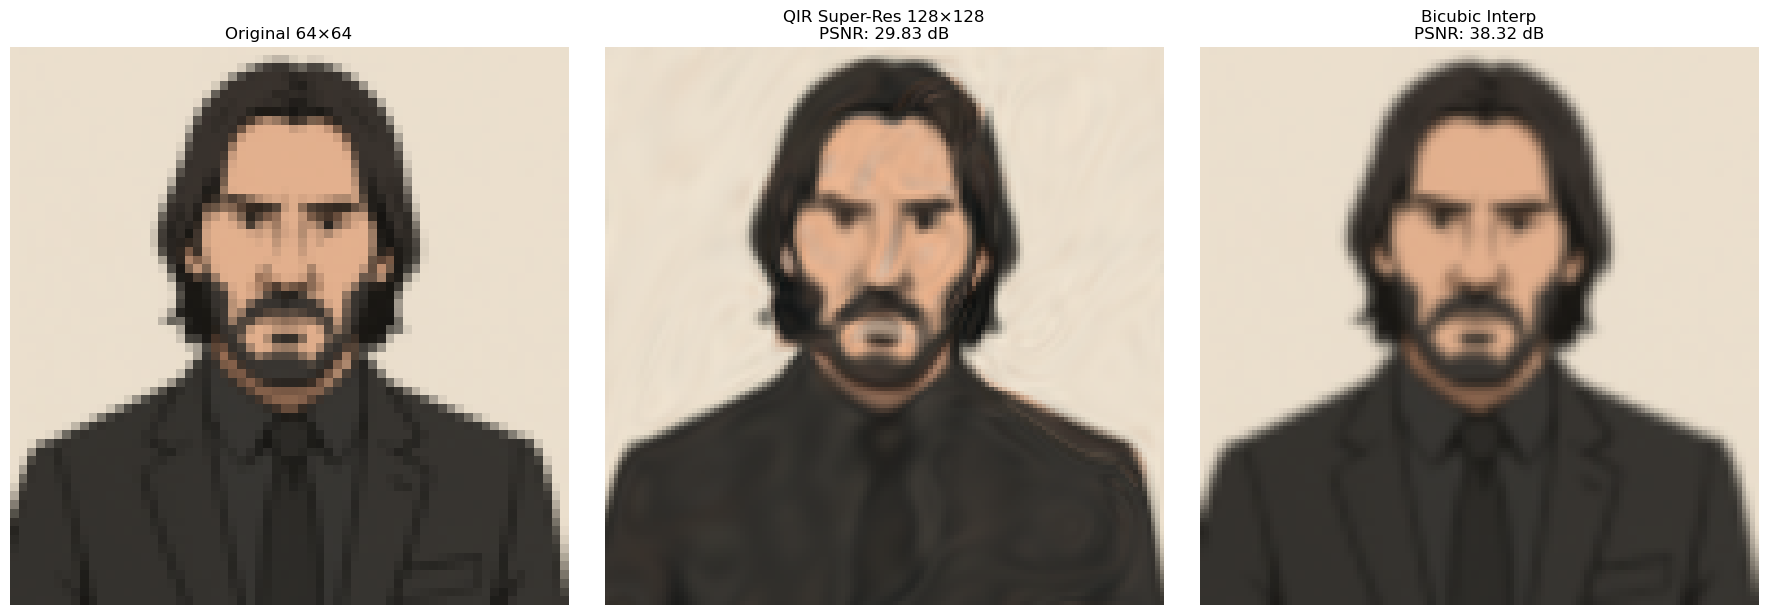

In [11]:
#Super Resolution Task




import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# --- Load and preprocess RGB image ---
img_path = "johnwick.png"
img = Image.open(img_path).convert("RGB")
img = img.resize((64, 64), Image.BILINEAR)
arr = np.array(img).astype("float32") / 255.0           # [H, W, 3]
H, W, C = arr.shape

# --- Super-res coordinates ---
scale = 2
Hr, Wr = H * scale, W * scale
coords_hr = get_rect_mgrid(Wr, Hr).to(device)           # [Wr*Hr, 2]
coords_hr_batch = coords_hr.unsqueeze(0)                # [1, Wr*Hr, 2]

# --- Inference from QIR model ---
with torch.no_grad():
    recon_hr_tensor, _ = loaded_model(coords_hr_batch)  # [1, Wr*Hr, 3]

recon_hr = (
        recon_hr_tensor.squeeze(0)      # [Wr*Hr, 3]
        .cpu()
        .view(Hr, Wr, 3)                # [Hr, Wr, 3]  
        .numpy()
    )
# --- Bicubic baseline (from original PIL image) ---
bicubic_hr = (
    np.array(img.resize((Wr, Hr), Image.BILINEAR)).astype("float32") / 255.0
)                                                       # [Hr, Wr, 3]

# --- PSNR computation function ---
def compute_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(max_val) - 10 * np.log10(mse)

# --- PSNR calculation ---
hr_gt = (
    np.array(img.resize((Wr, Hr), Image.BICUBIC)).astype("float32") / 255.0
)                                                       # [Hr, Wr, 3]

psnr_qir     = compute_psnr(hr_gt, recon_hr)
psnr_bicubic = compute_psnr(hr_gt, bicubic_hr)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(arr)
axes[0].set_title(f"Original {H}×{W}")
axes[0].axis("off")

axes[1].imshow(np.clip(recon_hr, 0, 1))
axes[1].set_title(f"QIR Super-Res {Hr}×{Wr}\nPSNR: {psnr_qir:.2f} dB")
axes[1].axis("off")

axes[2].imshow(np.clip(bicubic_hr, 0, 1))
axes[2].set_title(f"Bicubic Interp\nPSNR: {psnr_bicubic:.2f} dB")
axes[2].axis("off")

plt.tight_layout()
plt.show()

